In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['data.csv']))
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print(df.shape)
df.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print("=== SINIF DAĞILIMI ===")
print(df['diagnosis'].value_counts())

print("\n=== EKSİK VERİ KONTROLÜ ===")
print(f'Toplam eksik değer: {df.isnull().sum().sum()}')

=== SINIF DAĞILIMI ===
diagnosis
B    357
M    212
Name: count, dtype: int64

=== EKSİK VERİ KONTROLÜ ===
Toplam eksik değer: 0


In [ ]:
df = df.drop('id', axis=1)
print(df.shape)

(569, 31)


In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (569, 30)
y boyutu: (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)

Eğitim seti: (455, 30)
Test seti: (114, 30)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Ölçeklendirme tamamlandı!")
print("Örnek - ölçeklenmemiş ilk değer:", X_train.iloc[0, 0])
print("Örnek - ölçeklenmiş ilk değer:", X_train_scaled[0, 0])

Ölçeklendirme tamamlandı!
Örnek - ölçeklenmemiş ilk değer: 16.02
Örnek - ölçeklenmiş ilk değer: 0.5185587269315232


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

print("İlk 10 tahmin:", y_pred[:10])
print("Gerçek değerler:", y_test.values[:10])

İlk 10 tahmin: [0 1 0 1 0 0 1 0 0 0]
Gerçek değerler: [0 1 0 1 0 0 1 0 0 0]


In [ ]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("="*45)
print("        📊 DEĞERLENDİRME METRİKLERİ")
print("="*45)
print(f"Accuracy  (Doğruluk)   : %{acc*100:.2f}")
print(f"Precision (Kesinlik)   : %{prec*100:.2f}")
print(f"Recall    (Duyarlılık) : %{rec*100:.2f}")
print(f"F1-Score               : %{f1*100:.2f}")
print("="*45)

        📊 DEĞERLENDİRME METRİKLERİ
Accuracy  (Doğruluk)   : %97.37
Precision (Kesinlik)   : %100.00
Recall    (Duyarlılık) : %92.86
F1-Score               : %96.30


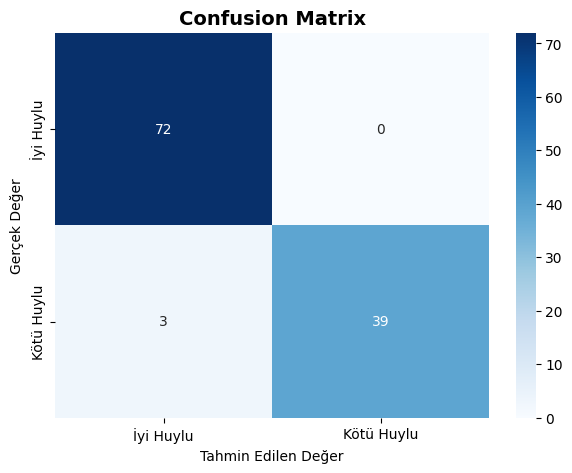

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['İyi Huylu', 'Kötü Huylu'],
            yticklabels=['İyi Huylu', 'Kötü Huylu'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin Edilen Değer')
plt.show()

In [17]:
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print(f"Eğitim seti doğruluğu : %{train_score*100:.2f}")
print(f"Test seti doğruluğu   : %{test_score*100:.2f}")
print(f"Fark                  : %{(train_score-test_score)*100:.2f}")


Eğitim seti doğruluğu : %100.00
Test seti doğruluğu   : %97.37
Fark                  : %2.63
